In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, gamma, lognorm, weibull_min, gaussian_kde, skew, genpareto


In [3]:
as_all = pd.read_excel('Biome Synbio Top Match EC Comparison.xlsx')
as_all = as_all[as_all['Percentage'] > 0]
as_lost = pd.read_excel('Lost_Functions.xlsx')
as_present = pd.read_excel('Only Present Enzyme Biome Synbio Top Match EC Comparison.xlsx')

#### Entire Biome Functional Space

Text(0.5, 1.0, 'Lognormal PDF of all Enzymatic Percantages')

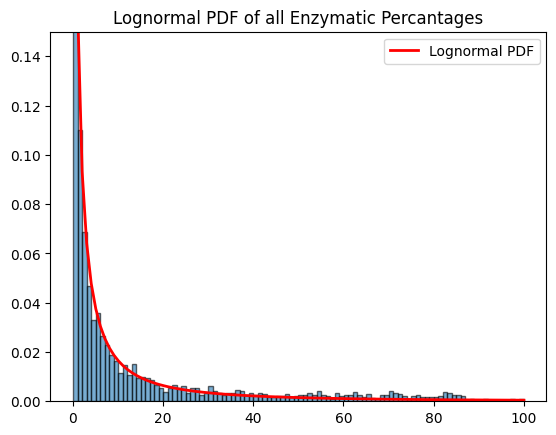

In [4]:
# sns.histplot(x='Percentage', data = as_all, kde=True)
##all_array
all_array = np.array(as_all['Percentage'])
#gamma
#lognormal
shape, loc, scale = lognorm.fit(all_array, floc = 0)
#weibull
# wb_fit = weibull_min.fit(all_array)

x = np.linspace(min(all_array), max(all_array), 100) #This creates an array of 100 evenly spaced datapoints within the min and max of the given dataset. This then gets fed into the gamma parameters to generate the PDF
pdf_fitted = lognorm.pdf(x, shape, loc=loc, scale=scale)

hist, bins, _ = plt.hist(all_array, bins=100, density=True, alpha=0.6, edgecolor='black')
plt.hist
# plt.plot(x, gamma.pdf(x, *g_fit), 'r-', label="Gamma fit")
plt.plot(x, pdf_fitted, 'r-', lw=2, label="Lognormal PDF")
plt.ylim(0, 0.150)
plt.legend()
plt.title('Lognormal PDF of all Enzymatic Percantages')

In [5]:
mean = lognorm.mean(shape, loc=loc, scale=scale)
median = lognorm.median(shape, loc=loc, scale=scale)
variance = lognorm.var(shape, loc=loc, scale=scale)
skewness = lognorm.stats(shape, loc=loc, scale=scale, moments='s')  # Skewness
kurtosis = lognorm.stats(shape, loc=loc, scale=scale, moments='k')  # Kurtosis

print(f"Mean: {mean}")
print(f"Variance: {variance}")
print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurtosis}")
print(f"Median: {median}")

Mean: 22.861965080256105
Variance: 28959.975849113413
Skewness: 434.76698204916585
Kurtosis: 10492622.280316086
Median: 3.04399468910012


### Present and Lost Functions

Text(0.5, 1.0, 'Percentages of Topmatch Functions Compared to Lost Functions With Gaussian KDE')

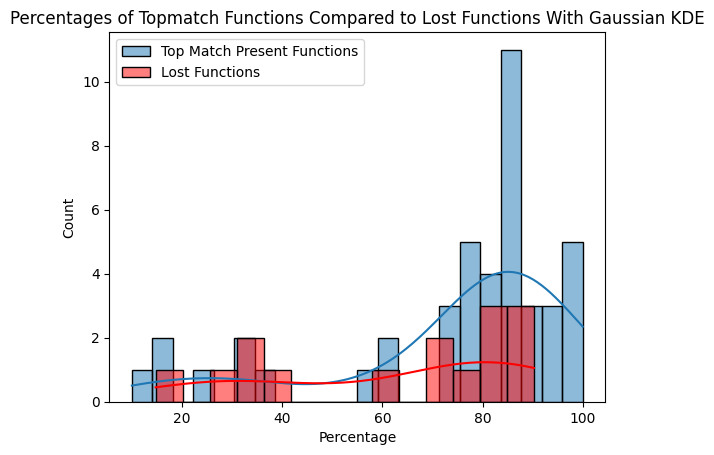

In [14]:
sns.histplot(x='Percentage', bins = 22, data = as_present, label = 'Top Match Present Functions', kde = True)
sns.histplot(x='Percentage',bins=14, data = as_lost, color = 'red', label='Lost Functions', kde= True)
plt.legend()
plt.title('Percentages of Topmatch Functions Compared to Lost Functions With Gaussian KDE')

In [7]:
present_array = np.array(as_present['Percentage'])
lost_array = np.array(as_lost['Percentage'])
shape2, loc2, scale2 = lognorm.fit(present_array, floc = 0)
shape3, loc3, scale3 = lognorm.fit(lost_array, floc = 0)

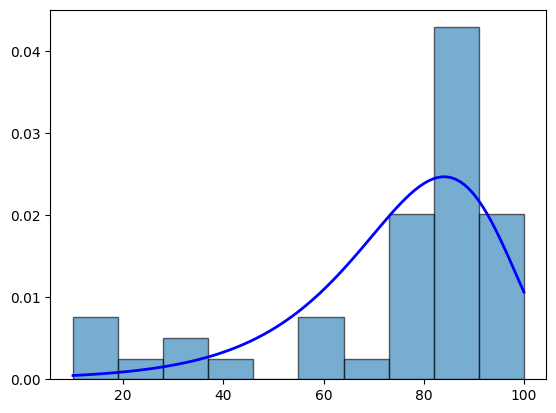

In [8]:
x2 = np.linspace(min(present_array), max(present_array), 100) #This creates an array of 100 evenly spaced datapoints within the min and max of the given dataset. This then gets fed into the gamma parameters to generate the PDF
x3 = np.linspace(min(lost_array), max(lost_array), 100) 

kde = gaussian_kde(present_array)
density = kde(x2)
wb_fit = weibull_min.fit(present_array)


plt.hist(present_array, density=True, alpha = 0.6, edgecolor = 'black')
plt.plot(x2, weibull_min.pdf(x2, *wb_fit), 'b-', lw=2, label="Weibull fit")



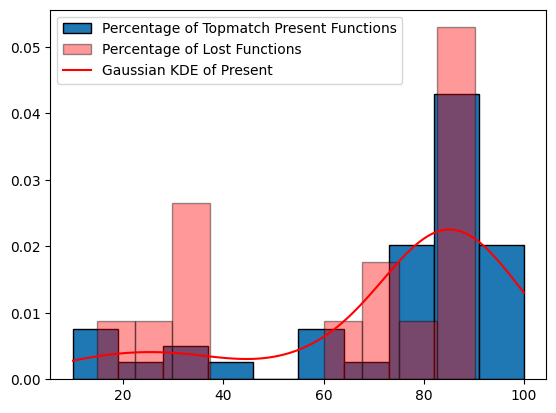

In [9]:
plt.hist(present_array, density=True, edgecolor = 'black', label = 'Percentage of Topmatch Present Functions')
plt.hist(lost_array,color='red', density=True, alpha = 0.4, edgecolor = 'black', label = 'Percentage of Lost Functions')
plt.plot(x2, density, color = 'red', label = 'Gaussian KDE of Present')
plt.legend()